In [1]:
import tensorflow as tf
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error
import os
import pandas as pd
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

2026-07-22 10:35:20.799027: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
years = [2008, 2009, 2010, 2011, 2012]
original_hrdps_dir = ("/results/forcing/atmospheric/GEM2.5/gemlam")
time_fixed_dir = ("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/TimeFixed")

fixed_2008_filenames = {
    "gemlam_y2008m07d16.nc",
    "gemlam_y2008m07d17.nc",
    "gemlam_y2008m07d18.nc",
    "gemlam_y2008m07d19.nc",
    "gemlam_y2008m07d20.nc",
    "gemlam_y2008m07d21.nc",
    "gemlam_y2008m07d22.nc",
    "gemlam_y2008m07d23.nc",
    'gemlam_y2008m08d10.nc',
    "gemlam_y2008m08d11.nc",
    "gemlam_y2008m08d12.nc",
}

hrdps_files_by_year = {}
for year in years:
    original_files = glob.glob(os.path.join(original_hrdps_dir,f"gemlam_y{year}m??d??.nc"))
    files_by_name = {os.path.basename(file): file for file in original_files}
    if year == 2008:
        for filename in fixed_2008_filenames:
            fixed_file = os.path.join(time_fixed_dir,filename,)
            files_by_name[filename] = fixed_file

    files = [files_by_name[filename] for filename in sorted(files_by_name)]

    hrdps_files_by_year[year] = files

    print(year,":",files[0],"to",files[-1],f"({len(files)} files)")

2008 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2008m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2008m12d31.nc (366 files)
2009 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2009m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2009m12d31.nc (365 files)
2010 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2010m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2010m12d31.nc (365 files)
2011 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m12d31.nc (365 files)
2012 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2012m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2012m12d31.nc (366 files)


In [3]:
# Loading datasets

weights_pre_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_pre22sep11.nc"
weights_post_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_22sep11onward.nc"
mesh_mask_file = "/ocean/dtaneja/MOAD/analysis-dishika/grid/mesh_mask202108.nc"

ds_weights_pre = xr.open_dataset(weights_pre_file).load()
ds_weights_post = xr.open_dataset(weights_post_file).load()

with xr.open_dataset(mesh_mask_file) as ds_mesh:
    nemo_lat = ds_mesh["nav_lat"].load()
    nemo_lon = ds_mesh["nav_lon"].load()

In [4]:
# Converts hourly HRDPS  from the 266 × 256 HRDPS grid to the 898 × 398 NEMO grid

transition_time = pd.Timestamp("2011-09-22 00:00:00")

def interpolate_therm_rad_with_weights(therm_rad, ds_weights):
    therm_rad = therm_rad.transpose("time_counter", "y", "x")

    n_time = therm_rad.sizes["time_counter"]
    source_shape = (therm_rad.sizes["y"],therm_rad.sizes["x"])
    n_source_cells = source_shape[0] * source_shape[1]

    source_values = (therm_rad.values.reshape(n_time, n_source_cells).astype(np.float32))
    target_shape = ds_weights["src01"].shape

    interpolated = np.zeros((n_time, target_shape[0], target_shape[1]),dtype=np.float32)

    for n in range(1, 5):
        # The source indexes in the weights file are 1-based
        source_index = (ds_weights[f"src{n:02d}"].values.astype(np.int64)- 1)
        weight = (ds_weights[f"wgt{n:02d}"].values.astype(np.float32))

        interpolated += (source_values[:, source_index]* weight[None, :, :])

    therm_rad_nemo = xr.DataArray(
        interpolated,
        dims=("time_counter", "y", "x"),
        coords={
            "time_counter": therm_rad["time_counter"],
            "nav_lat": (("y", "x"), nemo_lat.values),
            "nav_lon": (("y", "x"), nemo_lon.values),
        },
        name="therm_rad"
    )

    therm_rad_nemo.attrs = therm_rad.attrs.copy()
    therm_rad_nemo.attrs["grid"] = "SalishSeaCast NEMO grid"
    therm_rad_nemo.attrs["interpolation"] = (
        "Four-source weighted HRDPS-to-NEMO interpolation"
    )
    return therm_rad_nemo

In [5]:
# Open file and interpolates

def extract_and_interpolate_hourly_therm_rad(file):
    with xr.open_dataset(file) as ds:
        therm_rad = ds["therm_rad"].sortby("time_counter")
        time_index = therm_rad.get_index("time_counter")

        if time_index.has_duplicates:
            unique_mask = ~time_index.duplicated()
            therm_rad = therm_rad.isel(time_counter=unique_mask)

        therm_rad = therm_rad.load()

    times = pd.to_datetime(therm_rad["time_counter"].values)

    before_transition = times < transition_time
    after_transition = times >= transition_time

    pieces = []

    if before_transition.any():
        therm_rad_pre = therm_rad.isel(time_counter=np.where(before_transition)[0])
        interpolated_pre = interpolate_therm_rad_with_weights(therm_rad_pre,ds_weights_pre)
        pieces.append(interpolated_pre)

    if after_transition.any():
        therm_rad_post = therm_rad.isel(time_counter=np.where(after_transition)[0])
        interpolated_post = interpolate_therm_rad_with_weights(therm_rad_post,ds_weights_post)
        pieces.append(interpolated_post)

    therm_rad_nemo = xr.concat(pieces,dim="time_counter").sortby("time_counter")
    return therm_rad_nemo

In [6]:
with xr.open_dataset(mesh_mask_file) as ds_mesh:
    water_mask = (ds_mesh["tmask"].isel(t=0, z=0).load().values.astype(bool))
    nemo_lat_2d = ds_mesh["nav_lat"].load().values
    nemo_lon_2d = ds_mesh["nav_lon"].load().values
nemo_j, nemo_i = np.where(water_mask)
water_flat_indices = np.flatnonzero(water_mask.reshape(-1))
nemo_water_lat = nemo_lat_2d[water_mask]
nemo_water_lon = nemo_lon_2d[water_mask]
n_water = len(water_flat_indices)
print("NEMO grid shape:", water_mask.shape)
print("Number of surface water cells:", n_water)

NEMO grid shape: (898, 398)
Number of surface water cells: 81383


In [7]:
def process_daily_file_to_3h_water(file):
    therm_rad_nemo_hourly = extract_and_interpolate_hourly_therm_rad(file)
    n_time = therm_rad_nemo_hourly.sizes["time_counter"]

    therm_rad_water_values = (therm_rad_nemo_hourly.values.reshape(n_time, -1)[:, water_flat_indices].astype(np.float32))
    therm_rad_water_hourly = xr.DataArray(therm_rad_water_values,dims=("time_counter", "water_cell"),coords={
            "time_counter": therm_rad_nemo_hourly["time_counter"].values,
            "water_cell": np.arange(n_water, dtype=np.int32),},name="therm_rad",attrs=therm_rad_nemo_hourly.attrs,)

    therm_rad_water_3h = therm_rad_water_hourly.resample(time_counter="3h",label="left",closed="left",origin="start_day",).mean()
    return therm_rad_water_3h.load()

In [8]:
test_file = hrdps_files_by_year[2008][0]

test_3h = process_daily_file_to_3h_water(test_file)

print(test_3h)
print("Shape:", test_3h.shape)
print("Times:", test_3h.time_counter.values)

<xarray.DataArray 'therm_rad' (time_counter: 8, water_cell: 81383)> Size: 3MB
array([[254.25856, 254.50563, 254.80165, ..., 212.44531, 211.2187 ,
        209.82051],
       [254.0562 , 254.50995, 255.03642, ..., 263.59375, 261.60287,
        259.37183],
       [282.40344, 283.60526, 284.91504, ..., 282.67923, 281.46408,
        280.12332],
       ...,
       [270.80984, 271.97336, 273.18423, ..., 291.6092 , 291.0622 ,
        290.4569 ],
       [313.41724, 313.37048, 313.29858, ..., 296.4727 , 296.3238 ,
        296.16672],
       [327.19403, 327.20743, 327.24356, ..., 301.322  , 301.7306 ,
        302.15787]], dtype=float32)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 64B 2008-01-01 ... 2008-01-01...
  * water_cell    (water_cell) int32 326kB 0 1 2 3 4 ... 81379 81380 81381 81382
Attributes:
    level:          surface
    long_name:      Downward Long-Wave Radiation Flux
    standard_name:  net_downward_longwave_flux_in_air
    units:          W/m^2
    comment:     

In [9]:
hrdps_nemo_files = sorted(glob.glob("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/hrdps_nemo_3h/HRDPS_NEMO_*_therm_rad_3h.nc"))
ds_hrdps_nemo = xr.open_mfdataset(hrdps_nemo_files,combine="by_coords")

ds_hrdps_nemo = ds_hrdps_nemo.sortby("time_counter")

print(ds_hrdps_nemo)
print("First time:", ds_hrdps_nemo.time_counter.values[0])
print("Last time: ", ds_hrdps_nemo.time_counter.values[-1])
print("Shape:", ds_hrdps_nemo["therm_rad"].shape)

<xarray.Dataset> Size: 5GB
Dimensions:       (time_counter: 14608, water_cell: 81383)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 117kB 2008-01-01 ... 2012-12-...
  * water_cell    (water_cell) int32 326kB 0 1 2 3 4 ... 81379 81380 81381 81382
    nemo_j        (water_cell) int32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nemo_i        (water_cell) int32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nav_lat       (water_cell) float32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nav_lon       (water_cell) float32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
Data variables:
    therm_rad     (time_counter, water_cell) float32 5GB dask.array<chunksize=(366, 10173), meta=np.ndarray>
Attributes:
    description:  Raw hourly HRDPS therm_rad interpolated onto NEMO surface w...
First time: 2008-01-01T00:00:00.000000000
Last time:  2012-12-31T21:00:00.000000000
Shape: (14608, 81383)


In [10]:
# Validation: 2008
ds_hrdps_val = ds_hrdps_nemo.sel(time_counter=slice("2008-01-01", "2008-12-31 23:59:59"))
# Training: 2009–2011
ds_hrdps_train = ds_hrdps_nemo.sel(time_counter=slice("2009-01-01", "2011-12-31 23:59:59"))
# Testing: 2012
ds_hrdps_test = ds_hrdps_nemo.sel(time_counter=slice("2012-01-01", "2012-12-31 23:59:59"))

In [11]:
canrcm_years = [2008, 2009, 2010, 2011, 2012]
canrcm_rlds_files = []

for year in canrcm_years:
    matches = sorted(glob.glob(f"/results/forcing/CanRCM5/*_{year}01_{year}12_3h_rlds.nc"))
    canrcm_rlds_files.append(matches[0])

print("CanRCM files:")
for file in canrcm_rlds_files:
    print(file)

CanRCM files:
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200901_200912_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201001_201012_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201101_201112_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201201_201212_3h_rlds.nc


In [12]:
from datetime import timedelta
ds_canrcm = xr.open_mfdataset(canrcm_rlds_files,combine="by_coords")
ds_canrcm = ds_canrcm.sortby("time")
shifted_time = np.array([time_value - timedelta(hours=3)for time_value in ds_canrcm["time"].values])
ds_canrcm = ds_canrcm.assign_coords(time=("time", shifted_time))

print(ds_canrcm)
print("First timestamp:", ds_canrcm.time.values[0])
print("Last timestamp: ", ds_canrcm.time.values[-1])

<xarray.Dataset> Size: 7GB
Dimensions:       (time: 14600, bnds: 2, rlat: 320, rlon: 360)
Coordinates:
  * time          (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:0...
  * rlat          (rlat) float64 3kB -35.11 -34.89 -34.67 ... 34.63 34.85 35.07
  * rlon          (rlon) float64 3kB -39.27 -39.05 -38.83 ... 39.27 39.49 39.71
    lon           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
    lat           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 234kB dask.array<chunksize=(2920, 2), meta=np.ndarray>
    rotated_pole  (time) |S1 15kB b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
    rlds          (time, rlat, rlon) float32 7GB dask.array<chunksize=(2920, 320, 360), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    

/tmp/ipykernel_2044018/2851013810.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_canrcm = xr.open_mfdataset(canrcm_rlds_files,combine="by_coords")


In [13]:
nemo_water_lat = ds_hrdps_nemo["nav_lat"].values
nemo_water_lon = ds_hrdps_nemo["nav_lon"].values

nemo_water_lon_normalized = ((nemo_water_lon + 180) % 360) - 180

lat_min = float(np.nanmin(nemo_water_lat))
lat_max = float(np.nanmax(nemo_water_lat))

lon_min = float(np.nanmin(nemo_water_lon_normalized))
lon_max = float(np.nanmax(nemo_water_lon_normalized))

print("NEMO latitude range:", lat_min, "to", lat_max)
print("NEMO longitude range:", lon_min, "to", lon_max)

NEMO latitude range: 47.06300735473633 to 50.92766571044922
NEMO longitude range: -126.14797973632812 to -122.22117614746094


In [14]:
lat_canrcm = ds_canrcm["lat"]
lon_canrcm = ds_canrcm["lon"]

lon_canrcm_normalized = ((lon_canrcm + 180) % 360) - 180
canrcm_region_mask = ((lat_canrcm >= lat_min)& (lat_canrcm <= lat_max)
                      & (lon_canrcm_normalized >= lon_min) & (lon_canrcm_normalized <= lon_max))

rlat_indices, rlon_indices = np.where(canrcm_region_mask.values)

rlat_min = rlat_indices.min()
rlat_max = rlat_indices.max()

rlon_min = rlon_indices.min()
rlon_max = rlon_indices.max()

print("CanRCM rlat indices:", rlat_min, "to", rlat_max)
print("CanRCM rlon indices:", rlon_min, "to", rlon_max)

ds_canrcm_cut = (ds_canrcm[["rlds"]].isel(rlat=slice(rlat_min, rlat_max + 1),rlon=slice(rlon_min, rlon_max + 1)))
print(ds_canrcm_cut)

CanRCM rlat indices: 171 to 190
CanRCM rlon indices: 91 to 107
<xarray.Dataset> Size: 20MB
Dimensions:  (time: 14600, rlat: 20, rlon: 17)
Coordinates:
  * time     (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:00:00
  * rlat     (rlat) float64 160B 2.51 2.73 2.95 3.17 ... 6.03 6.25 6.47 6.69
  * rlon     (rlon) float64 136B -19.25 -19.03 -18.81 ... -16.17 -15.95 -15.73
    lon      (rlat, rlon) float64 3kB dask.array<chunksize=(20, 17), meta=np.ndarray>
    lat      (rlat, rlon) float64 3kB dask.array<chunksize=(20, 17), meta=np.ndarray>
Data variables:
    rlds     (time, rlat, rlon) float32 20MB dask.array<chunksize=(2920, 20, 17), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_member:  r1i1p1
    realization

In [15]:
# Validation: 2008
ds_canrcm_val = ds_canrcm_cut.sel(time=slice("2008-01-01","2008-12-31 23:59:59"))
# Training: 2009–2011
ds_canrcm_train = ds_canrcm_cut.sel(time=slice("2009-01-01","2011-12-31 23:59:59"))
# Testing: 2012
ds_canrcm_test = ds_canrcm_cut.sel(time=slice("2012-01-01","2012-12-31 23:59:59"))

In [16]:
def time_to_string(value):
    if isinstance(value, np.datetime64):
        return np.datetime_as_string(value,unit="s").replace("T", " ")

    if hasattr(value, "strftime"):
        return value.strftime("%Y-%m-%d %H:%M:%S")

    raise TypeError(f"Unsupported time type: {type(value)}")


def align_time_pair(ds_canrcm_split, ds_hrdps_split):
    canrcm_times = np.array([time_to_string(t)for t in ds_canrcm_split["time"].values])
    hrdps_times = np.array([time_to_string(t)for t in ds_hrdps_split["time_counter"].values])
    common_times, canrcm_idx, hrdps_idx = np.intersect1d(canrcm_times,hrdps_times,return_indices=True)
    ds_canrcm_aligned = ds_canrcm_split.isel(time=canrcm_idx)
    ds_hrdps_aligned = ds_hrdps_split.isel(time_counter=hrdps_idx)
    return ds_canrcm_aligned, ds_hrdps_aligned

In [17]:
ds_canrcm_val, ds_hrdps_val = align_time_pair(ds_canrcm_val,ds_hrdps_val)
ds_canrcm_train, ds_hrdps_train = align_time_pair(ds_canrcm_train,ds_hrdps_train)
ds_canrcm_test, ds_hrdps_test = align_time_pair(ds_canrcm_test,ds_hrdps_test)

In [18]:
print("Validation:")
print("HRDPS:", ds_hrdps_val.sizes["time_counter"])
print("CanRCM:", ds_canrcm_val.sizes["time"])

print("\nTraining:")
print("HRDPS:", ds_hrdps_train.sizes["time_counter"])
print("CanRCM:", ds_canrcm_train.sizes["time"])

print("\nTesting:")
print("HRDPS:", ds_hrdps_test.sizes["time_counter"])
print("CanRCM:", ds_canrcm_test.sizes["time"])

assert ds_hrdps_val.sizes["time_counter"] == ds_canrcm_val.sizes["time"]
assert ds_hrdps_train.sizes["time_counter"] == ds_canrcm_train.sizes["time"]
assert ds_hrdps_test.sizes["time_counter"] == ds_canrcm_test.sizes["time"]

Validation:
HRDPS: 2920
CanRCM: 2920

Training:
HRDPS: 8760
CanRCM: 8760

Testing:
HRDPS: 2912
CanRCM: 2912


In [19]:
X_hrdps_train_raw = (ds_hrdps_train["therm_rad"].values.astype(np.float32))
X_hrdps_val_raw = (ds_hrdps_val["therm_rad"].values.astype(np.float32))
X_hrdps_test_raw = (ds_hrdps_test["therm_rad"].values.astype(np.float32))

print("Raw HRDPS-NEMO train:", X_hrdps_train_raw.shape)
print("Raw HRDPS-NEMO val:  ", X_hrdps_val_raw.shape)
print("Raw HRDPS-NEMO test: ", X_hrdps_test_raw.shape)

Raw HRDPS-NEMO train: (8760, 81383)
Raw HRDPS-NEMO val:   (2920, 81383)
Raw HRDPS-NEMO test:  (2912, 81383)


In [20]:
valid_fraction_hrdps = np.isfinite(X_hrdps_train_raw).mean(axis=0)
valid_nemo_cols = valid_fraction_hrdps > 0.95

X_hrdps_train = X_hrdps_train_raw[:, valid_nemo_cols].copy()
X_hrdps_val = X_hrdps_val_raw[:, valid_nemo_cols].copy()
X_hrdps_test = X_hrdps_test_raw[:, valid_nemo_cols].copy()

hrdps_col_mean = np.nanmean(X_hrdps_train,axis=0)

if not np.all(np.isfinite(hrdps_col_mean)):
    raise ValueError(
        "At least one retained NEMO cell has a non-finite training mean."
    )


def fill_with_training_mean(X, training_mean):
    X = X.copy()
    rows, cols = np.where(~np.isfinite(X))
    X[rows, cols] = training_mean[cols]
    return X


X_hrdps_train = fill_with_training_mean(X_hrdps_train,hrdps_col_mean)
X_hrdps_val = fill_with_training_mean(X_hrdps_val,hrdps_col_mean)
X_hrdps_test = fill_with_training_mean(X_hrdps_test,hrdps_col_mean)

print("Valid NEMO cells:", valid_nemo_cols.sum())
print("Final HRDPS train:", X_hrdps_train.shape)
print("Final HRDPS val:  ", X_hrdps_val.shape)
print("Final HRDPS test: ", X_hrdps_test.shape)

Valid NEMO cells: 81383
Final HRDPS train: (8760, 81383)
Final HRDPS val:   (2920, 81383)
Final HRDPS test:  (2912, 81383)


In [21]:
valid_water_cell = (ds_hrdps_train["water_cell"].values[valid_nemo_cols])
valid_nemo_j = (ds_hrdps_train["nemo_j"].values[valid_nemo_cols])
valid_nemo_i = (ds_hrdps_train["nemo_i"].values[valid_nemo_cols])
valid_nemo_lat = (ds_hrdps_train["nav_lat"].values[valid_nemo_cols])
valid_nemo_lon = (ds_hrdps_train["nav_lon"].values[valid_nemo_cols])
print("Saved coordinate count:", len(valid_water_cell))

Saved coordinate count: 81383


In [22]:
def make_canrcm_matrix(da):
    da = da.transpose("time", "rlat", "rlon")
    n_time = da.sizes["time"]
    return (da.values.reshape(n_time, -1).astype(np.float32))

X_canrcm_train_raw = make_canrcm_matrix(ds_canrcm_train["rlds"])
X_canrcm_val_raw = make_canrcm_matrix(ds_canrcm_val["rlds"])
X_canrcm_test_raw = make_canrcm_matrix(ds_canrcm_test["rlds"])

print("Raw CanRCM train:", X_canrcm_train_raw.shape)
print("Raw CanRCM val:  ", X_canrcm_val_raw.shape)
print("Raw CanRCM test: ", X_canrcm_test_raw.shape)

Raw CanRCM train: (8760, 340)
Raw CanRCM val:   (2920, 340)
Raw CanRCM test:  (2912, 340)


In [23]:
valid_fraction_canrcm = np.isfinite(X_canrcm_train_raw).mean(axis=0)
valid_canrcm_cols = valid_fraction_canrcm > 0.95

X_canrcm_train = X_canrcm_train_raw[:,valid_canrcm_cols].copy()
X_canrcm_val = X_canrcm_val_raw[:,valid_canrcm_cols].copy()
X_canrcm_test = X_canrcm_test_raw[:,valid_canrcm_cols].copy()
canrcm_col_mean = np.nanmean(X_canrcm_train,axis=0)

if not np.all(np.isfinite(canrcm_col_mean)):
    raise ValueError(
        "At least one retained CanRCM cell has a non-finite training mean."
    )

X_canrcm_train = fill_with_training_mean(X_canrcm_train,canrcm_col_mean)
X_canrcm_val = fill_with_training_mean(X_canrcm_val,canrcm_col_mean)
X_canrcm_test = fill_with_training_mean(X_canrcm_test,canrcm_col_mean)
print("Final CanRCM train:", X_canrcm_train.shape)
print("Final CanRCM val:  ", X_canrcm_val.shape)
print("Final CanRCM test: ", X_canrcm_test.shape)

Final CanRCM train: (8760, 340)
Final CanRCM val:   (2920, 340)
Final CanRCM test:  (2912, 340)


In [24]:
hrdps_variance_threshold = 0.98
max_hrdps_pcs = min(300,X_hrdps_train.shape[0] - 1,X_hrdps_train.shape[1])
pca_hrdps = PCA(n_components=max_hrdps_pcs,svd_solver="randomized",random_state=0)
hrdps_train_scores_all = pca_hrdps.fit_transform(X_hrdps_train)
hrdps_cumulative_variance = np.cumsum(pca_hrdps.explained_variance_ratio_)
print("HRDPS PCA components:", pca_hrdps.components_.shape)
print("HRDPS training scores:", hrdps_train_scores_all.shape)
print("Variance explained by all searched PCs:",hrdps_cumulative_variance[-1])

HRDPS PCA components: (300, 81383)
HRDPS training scores: (8760, 300)
Variance explained by all searched PCs: 0.9955478


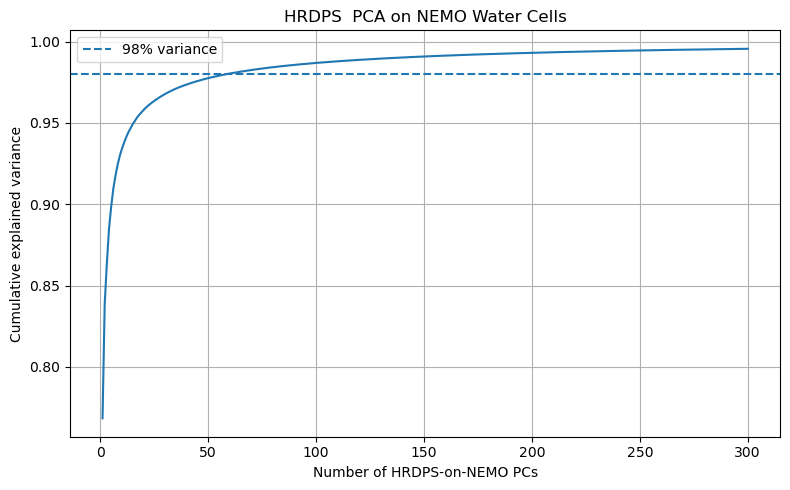

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(hrdps_cumulative_variance) + 1),hrdps_cumulative_variance)
plt.axhline(hrdps_variance_threshold,linestyle="--",label="98% variance")
plt.xlabel("Number of HRDPS-on-NEMO PCs")
plt.ylabel("Cumulative explained variance")
plt.title("HRDPS  PCA on NEMO Water Cells")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
threshold_indices = np.where(hrdps_cumulative_variance >= hrdps_variance_threshold)[0]
n_hrdps_pcs = threshold_indices[0] + 1
print("Selected HRDPS PCs:", n_hrdps_pcs)
print("Cumulative variance:",hrdps_cumulative_variance[n_hrdps_pcs - 1])

Selected HRDPS PCs: 59
Cumulative variance: 0.9801047


In [27]:
hrdps_train_scores = hrdps_train_scores_all[:, :n_hrdps_pcs]
hrdps_val_scores = pca_hrdps.transform(X_hrdps_val)[:, :n_hrdps_pcs]
hrdps_test_scores = pca_hrdps.transform(X_hrdps_test)[:, :n_hrdps_pcs]

print("HRDPS train scores:", hrdps_train_scores.shape)
print("HRDPS val scores:  ", hrdps_val_scores.shape)
print("HRDPS test scores: ", hrdps_test_scores.shape)

HRDPS train scores: (8760, 59)
HRDPS val scores:   (2920, 59)
HRDPS test scores:  (2912, 59)


In [28]:
max_canrcm_pcs = min(100,X_canrcm_train.shape[0] - 1,X_canrcm_train.shape[1])
pca_canrcm = PCA(n_components=max_canrcm_pcs,svd_solver="randomized",random_state=0)
canrcm_train_scores_all = pca_canrcm.fit_transform(X_canrcm_train)
canrcm_val_scores_all = pca_canrcm.transform(X_canrcm_val)
canrcm_test_scores_all = pca_canrcm.transform(X_canrcm_test)
canrcm_cumulative_variance = np.cumsum(pca_canrcm.explained_variance_ratio_)

print("CanRCM PCA components:", pca_canrcm.components_.shape)
print("CanRCM train scores:", canrcm_train_scores_all.shape)
print("CanRCM val scores:  ", canrcm_val_scores_all.shape)
print("CanRCM test scores: ", canrcm_test_scores_all.shape)

CanRCM PCA components: (100, 340)
CanRCM train scores: (8760, 100)
CanRCM val scores:   (2920, 100)
CanRCM test scores:  (2912, 100)


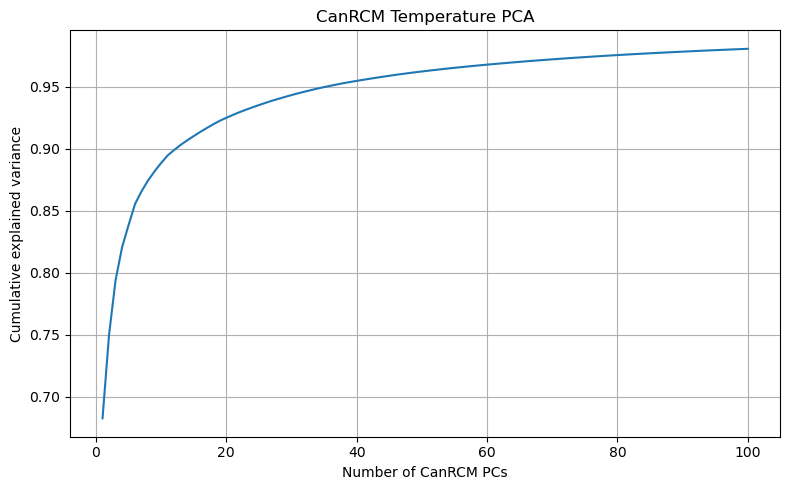

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(canrcm_cumulative_variance) + 1),canrcm_cumulative_variance)
plt.xlabel("Number of CanRCM PCs")
plt.ylabel("Cumulative explained variance")
plt.title("CanRCM Temperature PCA")
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
canrcm_pc_candidates = range(1,max_canrcm_pcs + 1)
val_r2_scores = []
for n_canrcm_pcs_candidate in canrcm_pc_candidates:
    X_train_pc = canrcm_train_scores_all[:,:n_canrcm_pcs_candidate]
    X_val_pc = canrcm_val_scores_all[:,:n_canrcm_pcs_candidate]
    model = LinearRegression()
    model.fit(X_train_pc,hrdps_train_scores)
    hrdps_val_scores_pred_candidate = model.predict(X_val_pc)
    val_r2 = r2_score(hrdps_val_scores,hrdps_val_scores_pred_candidate,multioutput="variance_weighted")
    val_r2_scores.append(val_r2)
val_r2_scores = np.array(val_r2_scores)

In [31]:
best_index = np.nanargmax(val_r2_scores)
n_canrcm_pcs = list(canrcm_pc_candidates)[best_index]
best_val_r2 = val_r2_scores[best_index]

print("Best number of CanRCM PCs:", n_canrcm_pcs)
print("Best validation PC-space R²:", best_val_r2)

Best number of CanRCM PCs: 73
Best validation PC-space R²: 0.6189713478088379


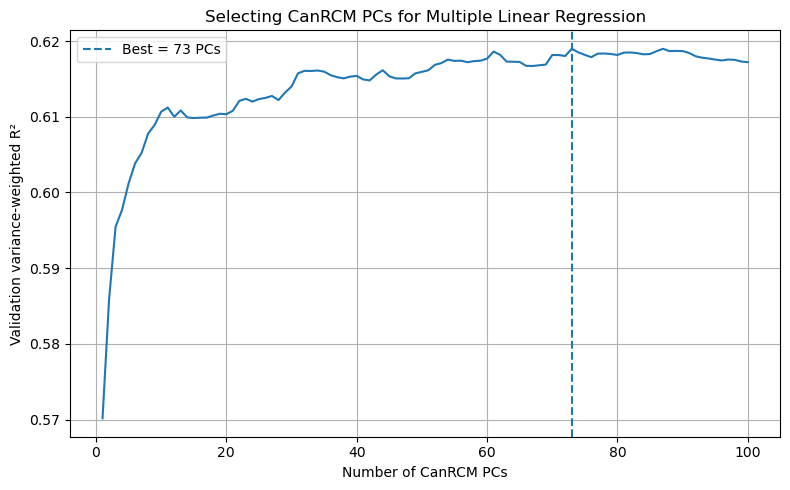

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(list(canrcm_pc_candidates),val_r2_scores)
plt.axvline(n_canrcm_pcs,linestyle="--",label=f"Best = {n_canrcm_pcs} PCs")
plt.xlabel("Number of CanRCM PCs")
plt.ylabel("Validation variance-weighted R²")
plt.title("Selecting CanRCM PCs for Multiple Linear Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
X_train_pc_final = canrcm_train_scores_all[:, :n_canrcm_pcs]
X_val_pc_final = canrcm_val_scores_all[:, :n_canrcm_pcs]
X_test_pc_final = canrcm_test_scores_all[:, :n_canrcm_pcs]

In [34]:
seed = 42

np.random.seed(seed)
tf.keras.utils.set_random_seed(seed)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.1


In [35]:
print("FCNN input shape:", X_train_pc_final.shape)
print("FCNN target shape:", hrdps_train_scores.shape)

FCNN input shape: (8760, 73)
FCNN target shape: (8760, 59)


In [81]:
canrcm_pc_scaler = StandardScaler()
hrdps_pc_scaler = StandardScaler()

X_train_nn = canrcm_pc_scaler.fit_transform(X_train_pc_final).astype(np.float32)
X_val_nn = canrcm_pc_scaler.transform(X_val_pc_final).astype(np.float32)
X_test_nn = canrcm_pc_scaler.transform(X_test_pc_final).astype(np.float32)

Y_train_nn = hrdps_pc_scaler.fit_transform(hrdps_train_scores).astype(np.float32)
Y_val_nn = hrdps_pc_scaler.transform(hrdps_val_scores).astype(np.float32)
Y_test_nn = hrdps_pc_scaler.transform(hrdps_test_scores).astype(np.float32)

In [82]:
print("Scaled training input:", X_train_nn.shape)
print("Scaled validation input:", X_val_nn.shape)
print("Scaled testing input:", X_test_nn.shape)

print("Scaled training target:", Y_train_nn.shape)
print("Scaled validation target:", Y_val_nn.shape)
print("Scaled testing target:", Y_test_nn.shape)

print("Maximum absolute training input:", np.abs(X_train_nn).max())
print("Maximum absolute training target:", np.abs(Y_train_nn).max())

Scaled training input: (8760, 73)
Scaled validation input: (2920, 73)
Scaled testing input: (2912, 73)
Scaled training target: (8760, 59)
Scaled validation target: (2920, 59)
Scaled testing target: (2912, 59)
Maximum absolute training input: 6.9164076
Maximum absolute training target: 9.044174


In [115]:
def build_pc_fcnn(n_input_pcs, n_output_pcs):
    regularizer = tf.keras.regularizers.l2(1e-4)

    inputs = tf.keras.layers.Input(shape=(n_input_pcs,), name="canrcm_pc_input")

    x = tf.keras.layers.Dense(64, activation="gelu", kernel_regularizer=regularizer, name="dense_1")(inputs)
    x = tf.keras.layers.Dropout(0.3, name="dropout_1")(x)

    x = tf.keras.layers.Dense(32, activation="gelu", kernel_regularizer=regularizer, name="dense_2")(x)
    x = tf.keras.layers.Dropout(0.3, name="dropout_2")(x)

    # x = tf.keras.layers.Dense(64, activation="gelu", kernel_regularizer=regularizer, name="dense_3")(x)

    outputs = tf.keras.layers.Dense(n_output_pcs, activation="linear", name="hrdps_pc_output")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="canrcm_to_hrdps_pc_fcnn")

    return model



In [116]:
n_canrcm_pcs = int(n_canrcm_pcs)
n_hrdps_pcs = int(n_hrdps_pcs)

print(type(n_canrcm_pcs), n_canrcm_pcs)
print(type(n_hrdps_pcs), n_hrdps_pcs)

<class 'int'> 73
<class 'int'> 59


In [117]:
tf.keras.backend.clear_session()
pc_fcnn = build_pc_fcnn(n_input_pcs=n_canrcm_pcs, n_output_pcs=n_hrdps_pcs)
optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4)

pc_fcnn.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
)
pc_fcnn.summary()

Model: "canrcm_to_hrdps_pc_fcnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ canrcm_pc_input (InputLayer)    │ (None, 73)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hrdps_pc_output (Dense)         │ (None, 59)             │         1,947 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,763 (34.23 KB)

 Trainable params: 8,763 (34.23 KB)

 Non-trainable params: 0 (0.00 B)

In [118]:
fcnn_output_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_temp"
os.makedirs(fcnn_output_dir, exist_ok=True)
checkpoint_path = os.path.join(fcnn_output_dir, "best_longwave_rad_pc_fcnn.keras")

In [119]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=18,
        min_delta=1e-5,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=6,
        min_lr=1e-6,
        verbose=1,
    ),
]

In [120]:
history = pc_fcnn.fit(
    X_train_nn,
    Y_train_nn,
    validation_data=(X_val_nn, Y_val_nn),
    epochs=300,
    batch_size=32,
    shuffle=True,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/300

Epoch 1: val_loss improved from None to 1.12514, saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_temp/best_longwave_rad_pc_fcnn.keras

Epoch 1: finished saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_temp/best_longwave_rad_pc_fcnn.keras
274/274 - 2s - 8ms/step - loss: 1.1788 - mae: 0.7722 - val_loss: 1.1251 - val_mae: 0.7492 - learning_rate: 3.0000e-04
Epoch 2/300

Epoch 2: val_loss improved from 1.12514 to 1.11251, saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_temp/best_longwave_rad_pc_fcnn.keras

Epoch 2: finished saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_temp/best_longwave_rad_pc_fcnn.keras
274/274 - 1s - 3ms/step - loss: 1.0535 - mae: 0.7218 - val_loss: 1.1125 - val_mae: 0.7432 - learning_rate: 3.0000e-04
Epoch 3/300

Epoch 3: val_loss improved from 1.11251 to 1.10734, saving model to /ocean/dtaneja/MOAD/an

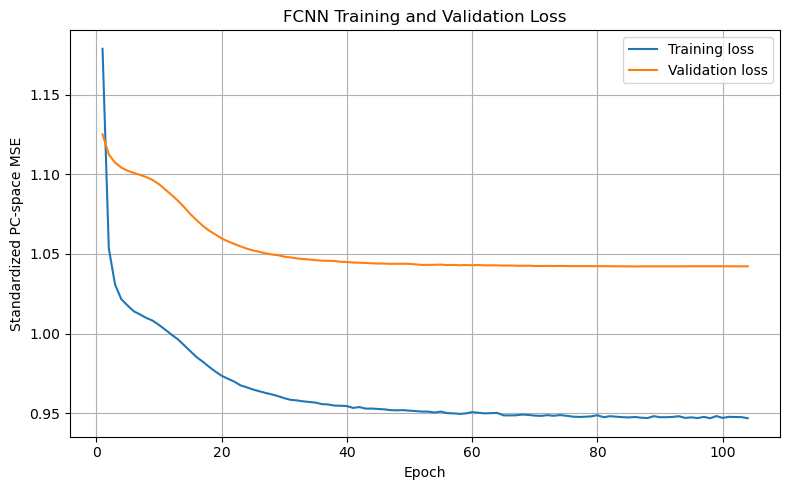

In [121]:
epochs_ran = range(1, len(history.history["loss"]) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history.history["loss"], label="Training loss")
plt.plot(epochs_ran, history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Standardized PC-space MSE")
plt.title("FCNN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

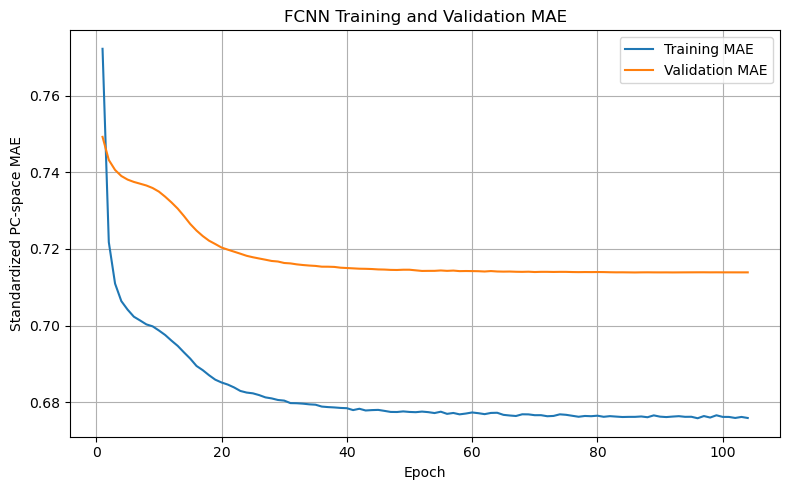

In [122]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history.history["mae"], label="Training MAE")
plt.plot(epochs_ran, history.history["val_mae"], label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("Standardized PC-space MAE")
plt.title("FCNN Training and Validation MAE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [123]:
best_pc_fcnn = tf.keras.models.load_model(checkpoint_path)

In [124]:
def predict_hrdps_pc_scores(model, X_scaled, target_scaler):
    predicted_scaled = model.predict(X_scaled, batch_size=256, verbose=1)
    predicted_scores = target_scaler.inverse_transform(predicted_scaled)
    return predicted_scores.astype(np.float32)

In [125]:
hrdps_val_scores_pred = predict_hrdps_pc_scores(best_pc_fcnn, X_val_nn, hrdps_pc_scaler)
hrdps_test_scores_pred = predict_hrdps_pc_scores(best_pc_fcnn, X_test_nn, hrdps_pc_scaler)
print("Predicted validation PC shape:", hrdps_val_scores_pred.shape)
print("Predicted test PC shape:", hrdps_test_scores_pred.shape)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Predicted validation PC shape: (2920, 59)
Predicted test PC shape: (2912, 59)


In [126]:
def calculate_pc_metrics(true_scores, predicted_scores):
    error = predicted_scores - true_scores
    return {
        "pc_rmse": float(np.sqrt(np.mean(error ** 2, dtype=np.float64))),
        "pc_mae": float(np.mean(np.abs(error), dtype=np.float64)),
        "pc_bias": float(np.mean(error, dtype=np.float64)),
        "pc_r2_variance_weighted": float(r2_score(true_scores, predicted_scores, multioutput="variance_weighted")),
    }

In [127]:
val_pc_metrics = calculate_pc_metrics(hrdps_val_scores, hrdps_val_scores_pred)
test_pc_metrics = calculate_pc_metrics(hrdps_test_scores, hrdps_test_scores_pred)
pc_metrics_table = pd.DataFrame([{"split": "validation", **val_pc_metrics}, {"split": "test", **test_pc_metrics}])
pc_metrics_table

,split,pc_rmse,pc_mae,pc_bias,pc_r2_variance_weighted
0,validation,833.057237,353.225277,15.903497,0.592406
1,test,805.903362,344.440545,16.337977,0.535389


In [128]:
selected_hrdps_components = (
    pca_hrdps.components_[
        :n_hrdps_pcs,
        :
    ]
)

In [129]:
def reconstruct_from_hrdps_pcs(pc_scores):
    reconstructed = np.dot(pc_scores, selected_hrdps_components) + pca_hrdps.mean_
    return reconstructed.astype(np.float32)

In [130]:
X_hrdps_val_pred = reconstruct_from_hrdps_pcs(hrdps_val_scores_pred)
X_hrdps_test_pred = reconstruct_from_hrdps_pcs(hrdps_test_scores_pred)
print("Validation reconstructed shape:", X_hrdps_val_pred.shape)
print("Test reconstructed shape:", X_hrdps_test_pred.shape)


Validation reconstructed shape: (2920, 81383)
Test reconstructed shape: (2912, 81383)


In [131]:
def calculate_field_metrics(true_values, predicted_values):
    error = predicted_values - true_values
    rmse = float(np.sqrt(np.mean(error**2, dtype=np.float64)))
    true_standard_deviation = float(np.std(true_values, dtype=np.float64))
    normalized_rmse = rmse / true_standard_deviation if true_standard_deviation > 0 else np.nan
    true_domain_mean = np.mean(true_values, axis=1)
    predicted_domain_mean = np.mean(predicted_values, axis=1)
    metrics = {"rmse": rmse, "normalized_rmse": float(normalized_rmse), "mae": float(np.mean(np.abs(error), dtype=np.float64)), "bias": float(np.mean(error, dtype=np.float64)), "grid_cell_r2": float(r2_score(true_values, predicted_values, multioutput="variance_weighted")), "domain_mean_r2": float(r2_score(true_domain_mean, predicted_domain_mean)), "number_valid_values": int(true_values.size)}
    return metrics

In [132]:
val_field_metrics = calculate_field_metrics(X_hrdps_val, X_hrdps_val_pred)
test_field_metrics = calculate_field_metrics(X_hrdps_test, X_hrdps_test_pred)

In [133]:
therm_rad_units = ds_hrdps_train["therm_rad"].attrs.get("units", "HRDPS therm_rad units")
field_metrics_table = pd.DataFrame([{"split": "validation", "units": therm_rad_units, **val_field_metrics}, {"split": "test", "units": therm_rad_units, **test_field_metrics}])
field_metrics_table

,split,units,rmse,normalized_rmse,mae,bias,grid_cell_r2,domain_mean_r2,number_valid_values
0,validation,W/m^2,23.000857,0.644033,18.072406,2.734424,0.580209,0.707632,237638360
1,test,W/m^2,22.360843,0.688567,17.338354,4.757646,0.520224,0.669687,236987296


In [57]:
X_hrdps_val_selected_pc_reconstruction = reconstruct_from_hrdps_pcs(hrdps_val_scores)
X_hrdps_test_selected_pc_reconstruction = reconstruct_from_hrdps_pcs(hrdps_test_scores)

In [58]:
pca_only_metrics_table = pd.DataFrame(
    [
        {
            "split": "validation",
            **calculate_field_metrics(
                X_hrdps_val,
                X_hrdps_val_selected_pc_reconstruction,
            ),
        },
        {
            "split": "test",
            **calculate_field_metrics(
                X_hrdps_test,
                X_hrdps_test_selected_pc_reconstruction,
            ),
        },
    ]
)

pca_only_metrics_table

,split,rmse,normalized_rmse,mae,bias,grid_cell_r2,domain_mean_r2,number_valid_values
0,validation,5.091574,0.142566,3.111521,-0.000069,0.979429,1.0,237638360
1,test,5.399648,0.166274,3.264580,-0.000188,0.972023,1.0,236987296


In [59]:
def values_to_datetime_index(time_values):
    return pd.DatetimeIndex([pd.Timestamp(time_to_string(value)) for value in time_values])

In [60]:
val_times = values_to_datetime_index(ds_hrdps_val["time_counter"].values)
test_times = values_to_datetime_index(ds_hrdps_test["time_counter"].values)
print(val_times[0], val_times[-1], len(val_times))
print(test_times[0], test_times[-1], len(test_times))

2008-01-01 00:00:00 2008-12-31 21:00:00 2920
2012-01-01 00:00:00 2012-12-31 21:00:00 2912


In [61]:
def plot_domain_mean_timeseries(times, true_values, predicted_values, split_name, frequency=None):
    true_mean = np.mean(true_values, axis=1)
    predicted_mean = np.mean(predicted_values, axis=1)
    time_series = pd.DataFrame({"Actual": true_mean, "Predicted": predicted_mean}, index=times)
    if frequency is not None:
        time_series = time_series.resample(frequency).mean()
    plt.figure(figsize=(14, 5))
    plt.plot(time_series.index, time_series["Actual"], label="Actual HRDPS", linewidth=1.5)
    plt.plot(time_series.index, time_series["Predicted"], label="Predicted FCNN", linewidth=1.5)
    frequency_label = "Daily Mean" if frequency == "D" else "3-Hourly"
    plt.xlabel("Date")
    plt.ylabel(f"Spatial mean therm_rad ({therm_rad_units})")
    plt.title(f"{split_name}: {frequency_label} Spatial Mean Temperature")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return time_series

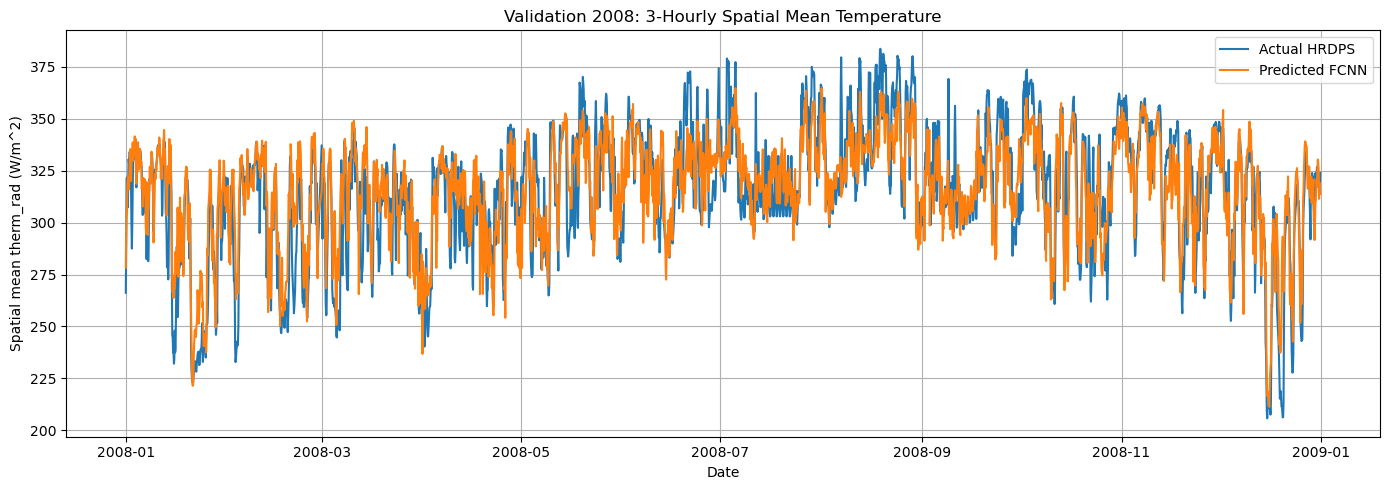

In [62]:
val_domain_3h = (
    plot_domain_mean_timeseries(
        times=val_times,
        true_values=X_hrdps_val,
        predicted_values=X_hrdps_val_pred,
        split_name="Validation 2008",
        frequency=None,
    )
)

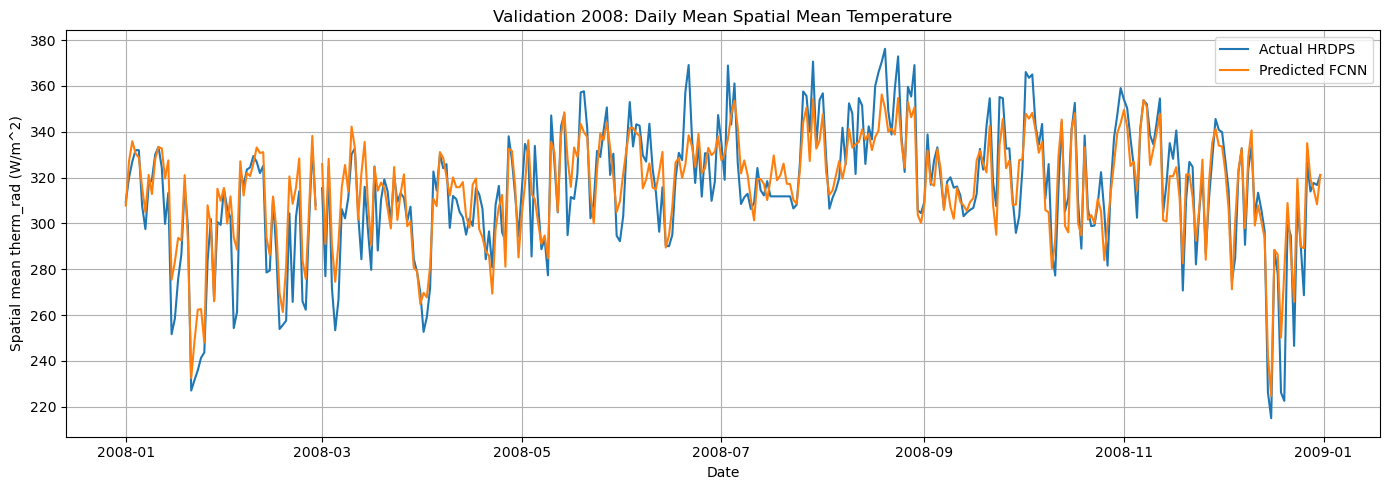

In [63]:
val_domain_daily = (
    plot_domain_mean_timeseries(
        times=val_times,
        true_values=X_hrdps_val,
        predicted_values=X_hrdps_val_pred,
        split_name="Validation 2008",
        frequency="D",
    )
)

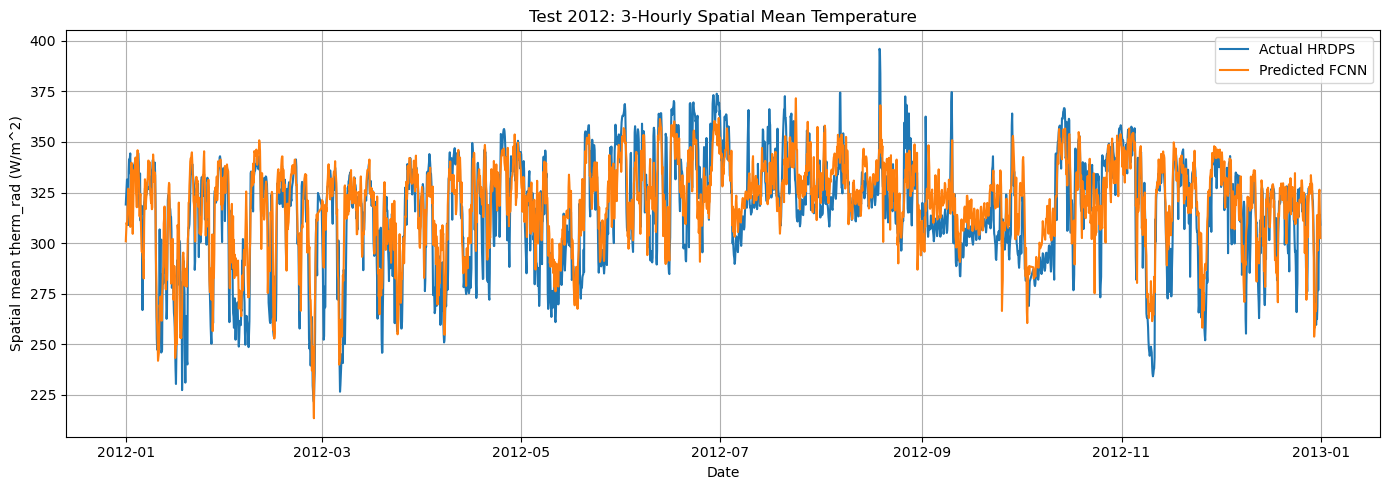

In [64]:
test_domain_3h = (
    plot_domain_mean_timeseries(
        times=test_times,
        true_values=X_hrdps_test,
        predicted_values=X_hrdps_test_pred,
        split_name="Test 2012",
        frequency=None,
    )
)

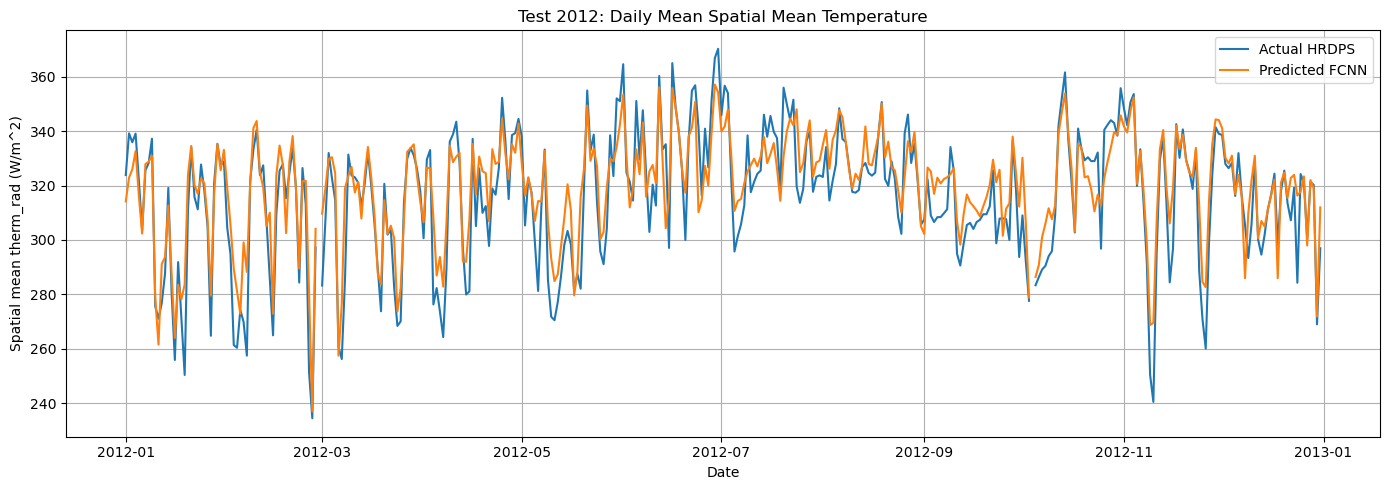

In [65]:
test_domain_daily = (
    plot_domain_mean_timeseries(
        times=test_times,
        true_values=X_hrdps_test,
        predicted_values=X_hrdps_test_pred,
        split_name="Test 2012",
        frequency="D",
    )
)

In [66]:
stations = {
    "Sand Heads": {
        "j": 426,
        "i": 293,
    },
    "Halibut Bank": {
        "j": 503,
        "i": 261,
    },
    "Sentry Shoal": {
        "j": 707,
        "i": 145,
    },
}

In [67]:
def find_station_column(station_j, station_i):
    exact_match = np.where((valid_nemo_j == station_j) & (valid_nemo_i == station_i))[0]
    if len(exact_match) == 1:
        return int(exact_match[0])
    if len(exact_match) > 1:
        raise ValueError("More than one matrix column matches the station cell.")
    squared_distance = (valid_nemo_j - station_j) ** 2 + (valid_nemo_i - station_i) ** 2
    nearest_column = int(np.argmin(squared_distance))
    print("Exact retained cell not found for", (station_j, station_i), "Using nearest retained cell:", (int(valid_nemo_j[nearest_column]), int(valid_nemo_i[nearest_column])))
    return nearest_column

In [68]:
station_columns = {}
for station_name, station_info in stations.items():
    column = find_station_column(station_info["j"], station_info["i"])
    station_columns[station_name] = column
    print(station_name, "column:", column, "NEMO cell:", (int(valid_nemo_j[column]), int(valid_nemo_i[column])), "latitude:", float(valid_nemo_lat[column]), "longitude:", float(valid_nemo_lon[column]))

Sand Heads column: 44165 NEMO cell: (426, 293) latitude: 49.099735260009766 longitude: -123.29531860351562
Halibut Bank column: 53329 NEMO cell: (503, 261) latitude: 49.3411979675293 longitude: -123.71952056884766
Sentry Shoal column: 71870 NEMO cell: (707, 145) latitude: 49.92068862915039 longitude: -125.00068664550781


In [69]:
def calculate_series_metrics(true_series, predicted_series):
    error = predicted_series - true_series
    return {
        "rmse": float(np.sqrt(np.mean(error ** 2, dtype=np.float64))),
        "mae": float(np.mean(np.abs(error), dtype=np.float64)),
        "bias": float(np.mean(error, dtype=np.float64)),
        "r2": float(r2_score(true_series, predicted_series)),
        "number_values": int(len(true_series)),
    }

In [70]:
station_metric_rows = []
split_data = {"validation": {"true": X_hrdps_val, "predicted": X_hrdps_val_pred}, "test": {"true": X_hrdps_test, "predicted": X_hrdps_test_pred}}
for split_name, values in split_data.items():
    for station_name, column in station_columns.items():
        true_station = values["true"][:, column]
        predicted_station = values["predicted"][:, column]
        station_metrics = calculate_series_metrics(true_station, predicted_station)
        station_metric_rows.append({"split": split_name, "station": station_name, "nemo_j": int(valid_nemo_j[column]), "nemo_i": int(valid_nemo_i[column]), "latitude": float(valid_nemo_lat[column]), "longitude": float(valid_nemo_lon[column]), "units": therm_rad_units, **station_metrics})

In [71]:
station_metrics_table = pd.DataFrame(
    station_metric_rows
)

station_metrics_table

,split,station,nemo_j,nemo_i,latitude,longitude,units,rmse,mae,bias,r2,number_values
0,validation,Sand Heads,426,293,49.099735,-123.295319,W/m^2,23.607954,18.359186,1.435328,0.584193,2920
1,validation,Halibut Bank,503,261,49.341198,-123.719521,W/m^2,23.325707,18.289839,1.617566,0.585963,2920
2,validation,Sentry Shoal,707,145,49.920689,-125.000687,W/m^2,22.932872,17.868890,0.956298,0.612220,2920
3,test,Sand Heads,426,293,49.099735,-123.295319,W/m^2,22.515083,17.376521,3.596869,0.509808,2912
4,test,Halibut Bank,503,261,49.341198,-123.719521,W/m^2,22.156640,17.120503,3.970222,0.526446,2912
5,test,Sentry Shoal,707,145,49.920689,-125.000687,W/m^2,22.660573,17.123428,3.731551,0.528427,2912


In [72]:
average_station_rmse = (
    station_metrics_table
    .groupby("split")["rmse"]
    .mean()
    .reset_index(
        name="average_station_rmse"
    )
)

average_station_rmse

,split,average_station_rmse
0,test,22.444098
1,validation,23.288844


In [73]:
def plot_station_timeseries(
    times,
    true_values,
    predicted_values,
    station_name,
    station_column,
    split_name,
    frequency="D",
):
    station_series = pd.DataFrame(
        {
            "Actual": (
                true_values[
                    :,
                    station_column,
                ]
            ),
            "Predicted": (
                predicted_values[
                    :,
                    station_column,
                ]
            ),
        },
        index=times,
    )

    if frequency is not None:
        station_series = (
            station_series
            .resample(frequency)
            .mean()
        )

    plt.figure(
        figsize=(14, 5)
    )

    plt.plot(
        station_series.index,
        station_series["Actual"],
        label="Actual HRDPS",
        linewidth=1.5,
    )

    plt.plot(
        station_series.index,
        station_series["Predicted"],
        label="Predicted FCNN",
        linewidth=1.5,
    )

    if frequency == "D":
        frequency_label = "Daily Mean"
    else:
        frequency_label = "3-Hourly"

    plt.xlabel("Date")
    plt.ylabel(
        f"Temperature ({therm_rad_units})"
    )

    plt.title(
        f"{split_name}: "
        f"{station_name} "
        f"{frequency_label} Temperature"
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return station_series

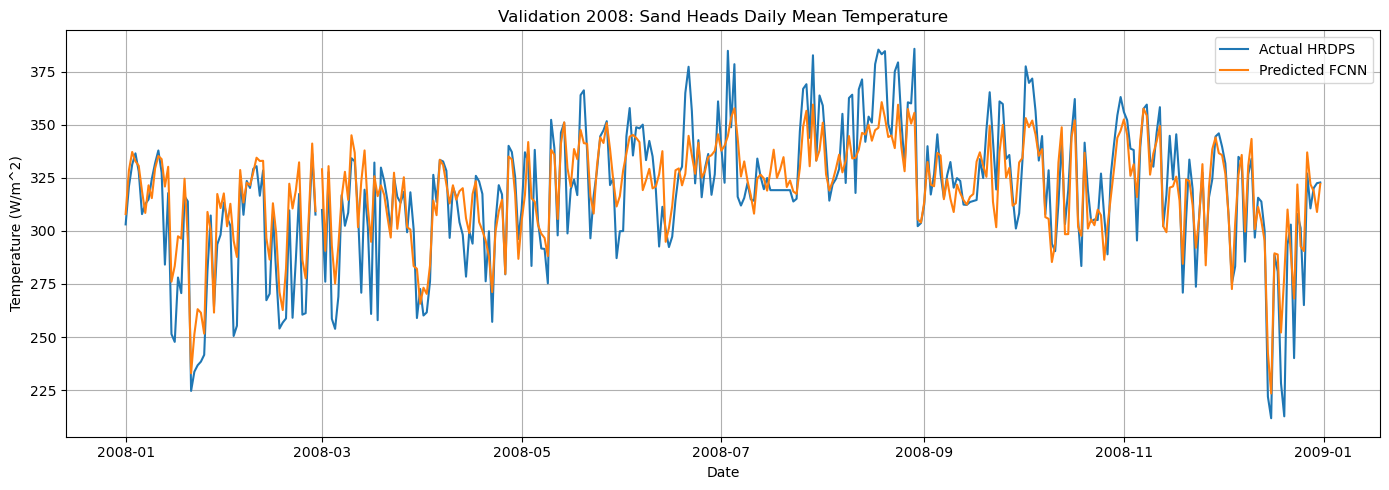

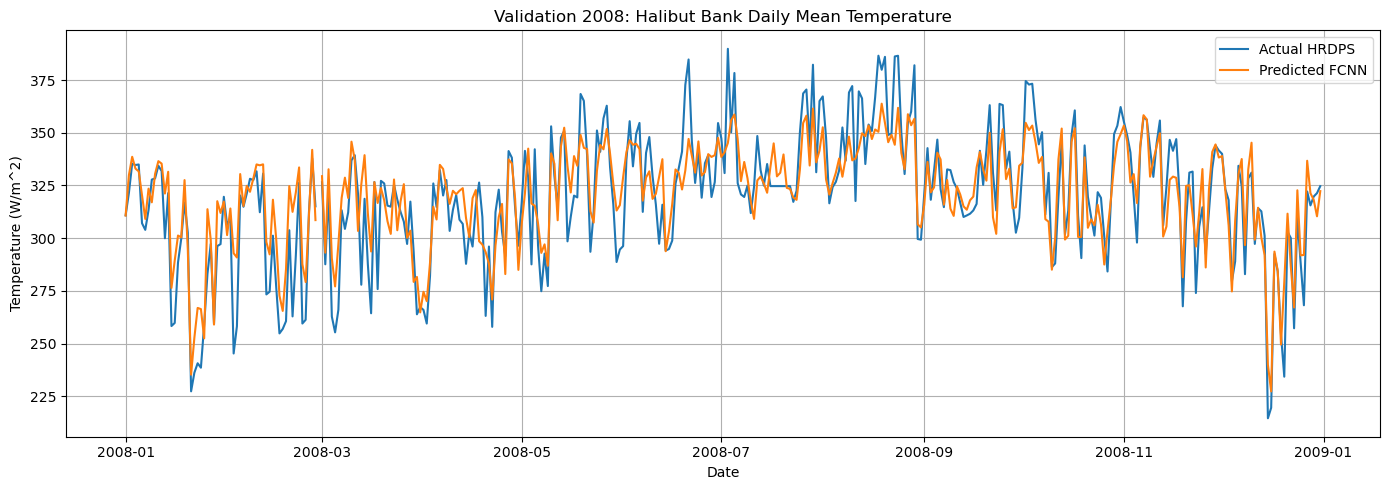

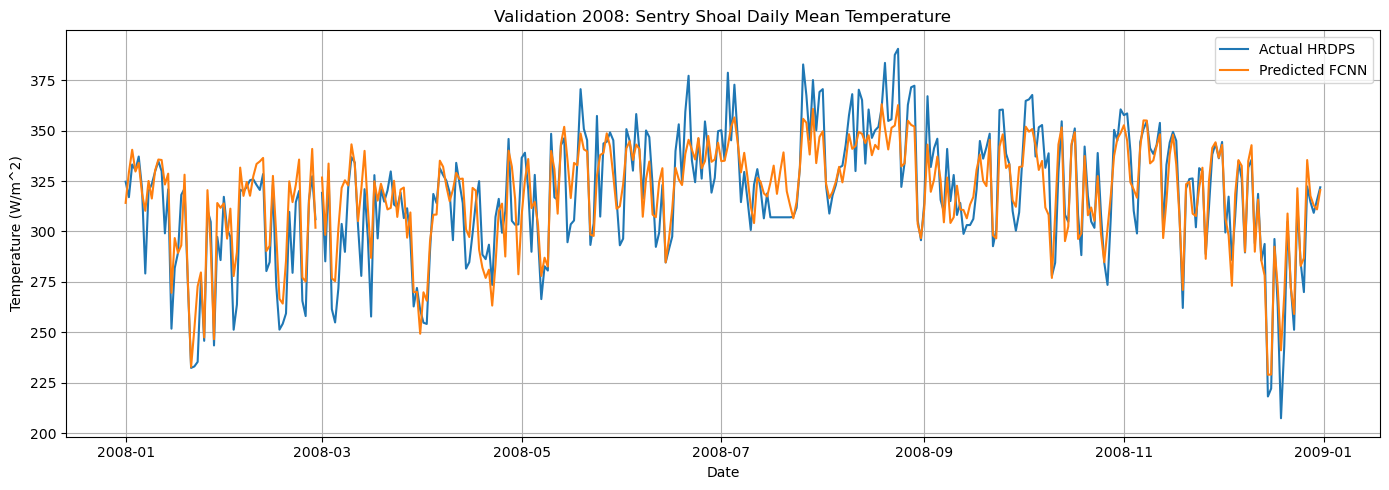

In [74]:
validation_station_series = {}

for station_name, column in station_columns.items():
    validation_station_series[
        station_name
    ] = plot_station_timeseries(
        times=val_times,
        true_values=X_hrdps_val,
        predicted_values=X_hrdps_val_pred,
        station_name=station_name,
        station_column=column,
        split_name="Validation 2008",
        frequency="D",
    )

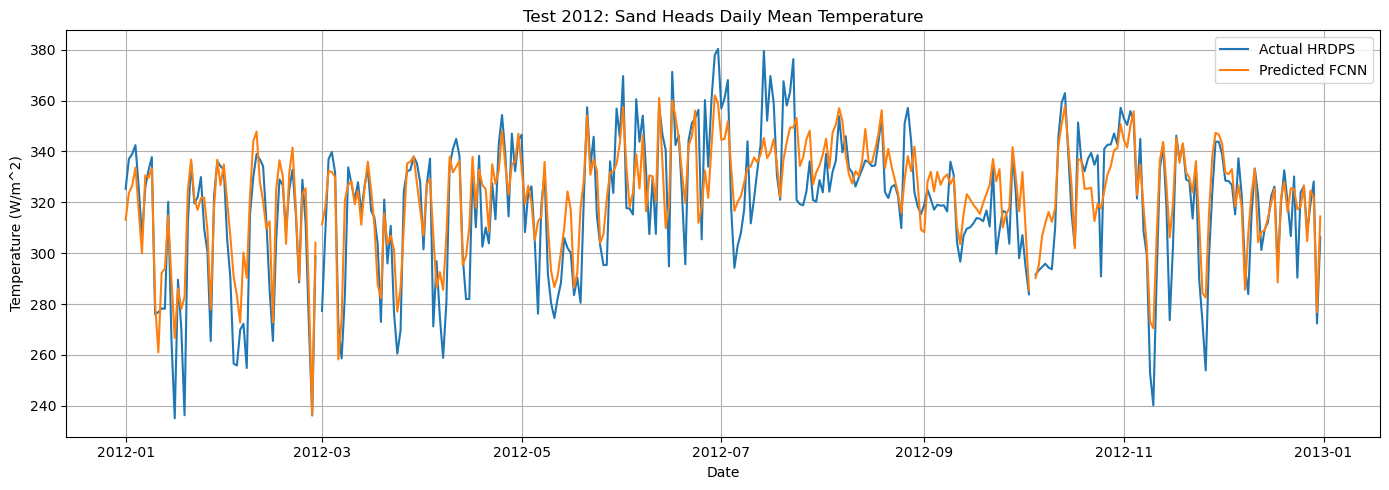

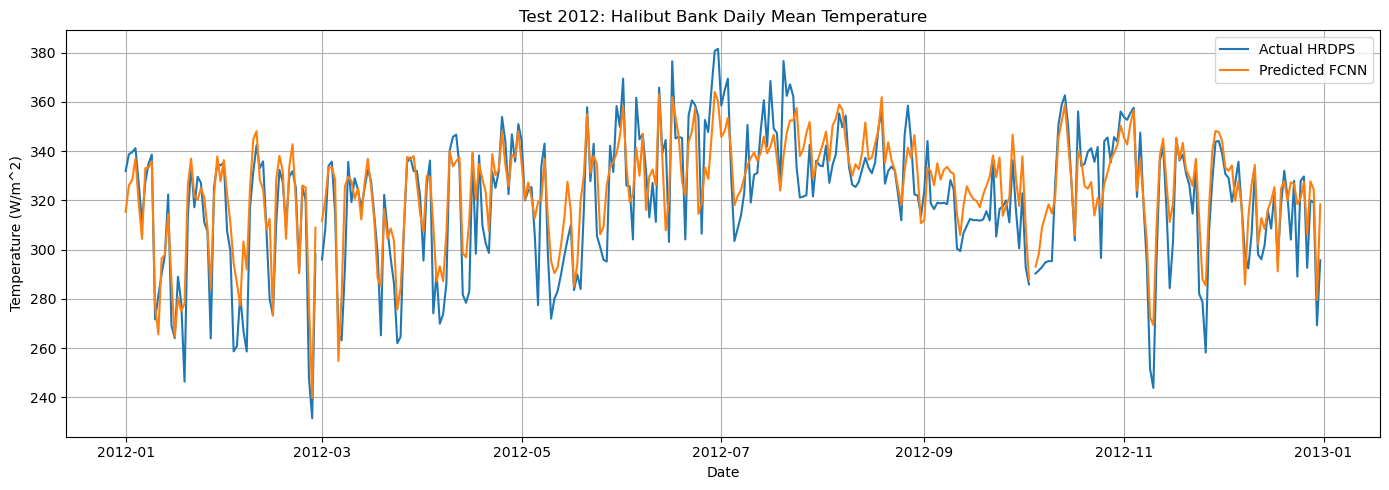

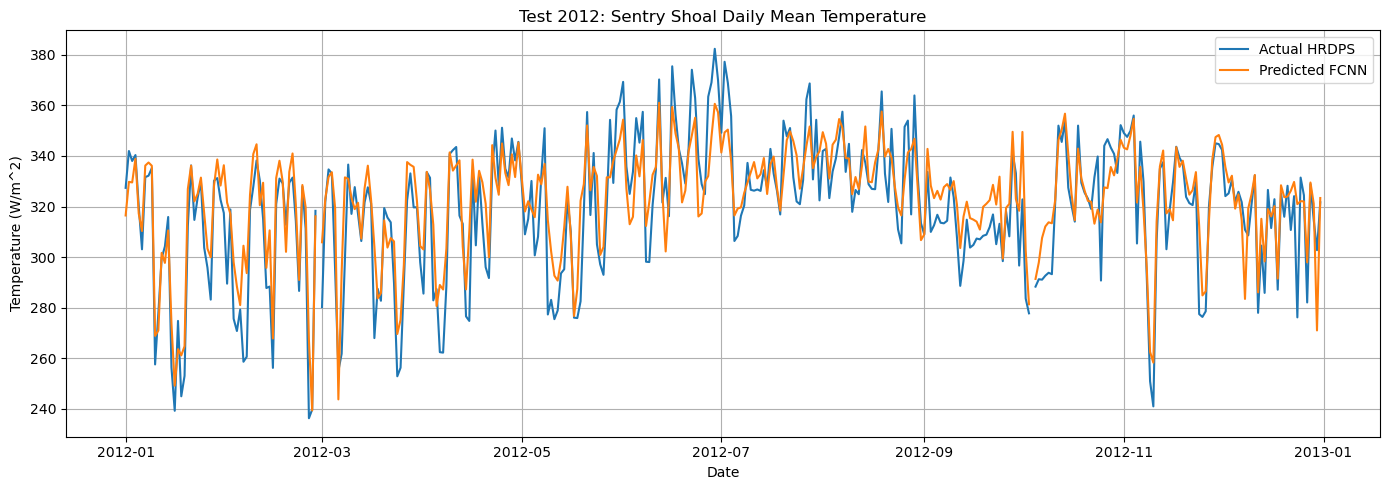

In [75]:
test_station_series = {}

for station_name, column in station_columns.items():
    test_station_series[
        station_name
    ] = plot_station_timeseries(
        times=test_times,
        true_values=X_hrdps_test,
        predicted_values=X_hrdps_test_pred,
        station_name=station_name,
        station_column=column,
        split_name="Test 2012",
        frequency="D",
    )

In [76]:
def vector_to_nemo_map(vector):
    nemo_map = np.full(water_mask.shape, np.nan, dtype=np.float32)
    nemo_map[valid_nemo_j.astype(int), valid_nemo_i.astype(int)] = vector
    return nemo_map

In [77]:
example_map = vector_to_nemo_map(X_hrdps_test[0])
print("Map shape:", example_map.shape)
print("Number of finite cells:", np.isfinite(example_map).sum())

Map shape: (898, 398)
Number of finite cells: 81383


In [78]:
def plot_spatial_pattern(times, true_values, predicted_values, requested_timestamp, split_name):
    requested_timestamp = pd.Timestamp(requested_timestamp)
    time_index = times.get_indexer([requested_timestamp], method="nearest")[0]
    selected_timestamp = times[time_index]
    true_map = vector_to_nemo_map(true_values[time_index])
    predicted_map = vector_to_nemo_map(predicted_values[time_index])
    error_map = predicted_map - true_map
    true_and_predicted = np.concatenate([true_map[np.isfinite(true_map)], predicted_map[np.isfinite(predicted_map)]])
    temperature_vmin = np.nanpercentile(true_and_predicted, 2)
    temperature_vmax = np.nanpercentile(true_and_predicted, 98)
    error_limit = np.nanpercentile(np.abs(error_map), 98)
    if not np.isfinite(error_limit) or error_limit == 0:
        error_limit = 1e-6
    figure, axes = plt.subplots(1, 3, figsize=(19, 6), constrained_layout=True)
    actual_mesh = axes[0].pcolormesh(nemo_lon_2d, nemo_lat_2d, true_map, shading="auto", cmap="viridis", vmin=temperature_vmin, vmax=temperature_vmax)
    axes[0].set_title("Actual HRDPS")
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")
    predicted_mesh = axes[1].pcolormesh(nemo_lon_2d, nemo_lat_2d, predicted_map, shading="auto", cmap="viridis", vmin=temperature_vmin, vmax=temperature_vmax)
    axes[1].set_title("Predicted FCNN")
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")
    error_mesh = axes[2].pcolormesh(nemo_lon_2d, nemo_lat_2d, error_map, shading="auto", cmap="RdBu_r", vmin=-error_limit, vmax=error_limit)
    axes[2].set_title("Prediction − Actual")
    axes[2].set_xlabel("Longitude")
    axes[2].set_ylabel("Latitude")
    figure.colorbar(actual_mesh, ax=axes[:2], label=f"Temperature ({therm_rad_units})", shrink=0.85)
    figure.colorbar(error_mesh, ax=axes[2], label=f"Temperature error ({therm_rad_units})", shrink=0.85)
    figure.suptitle(f"{split_name}: {selected_timestamp}")
    plt.show()
    print("Requested timestamp:", requested_timestamp)
    print("Selected timestamp:", selected_timestamp)

/tmp/ipykernel_2044018/1886328085.py:15: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  actual_mesh = axes[0].pcolormesh(nemo_lon_2d, nemo_lat_2d, true_map, shading="auto", cmap="viridis", vmin=temperature_vmin, vmax=temperature_vmax)
/tmp/ipykernel_2044018/1886328085.py:19: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  predicted_mesh = axes[1].pcolormesh(nemo_lon_2d, nemo_lat_2d, predicted_map, shading="auto", cmap="viridis", vmin=temperature_vmin, vmax=temperature_vmax)
/tmp/ipykernel_2044018/1886328085.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cel

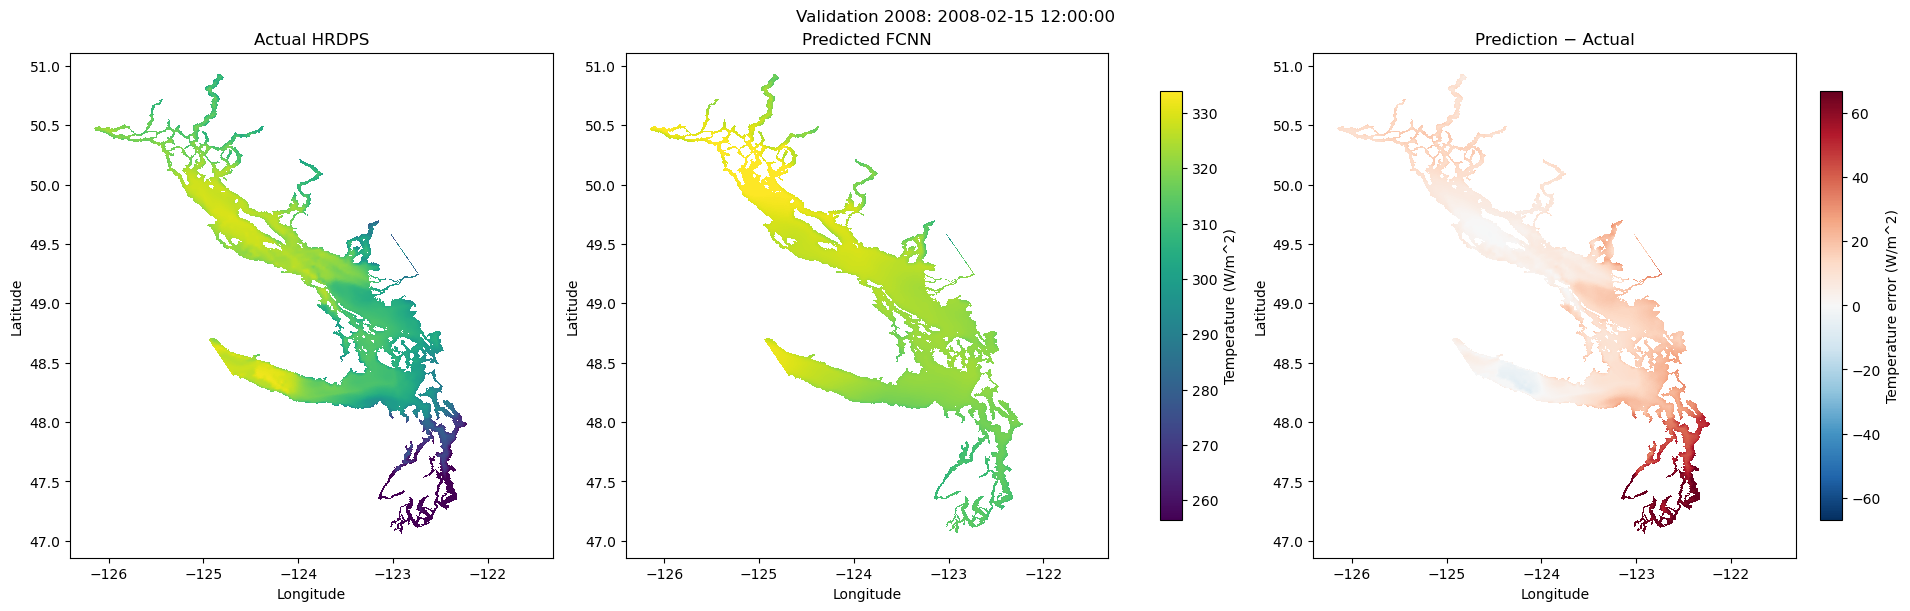

Requested timestamp: 2008-02-15 12:00:00
Selected timestamp: 2008-02-15 12:00:00


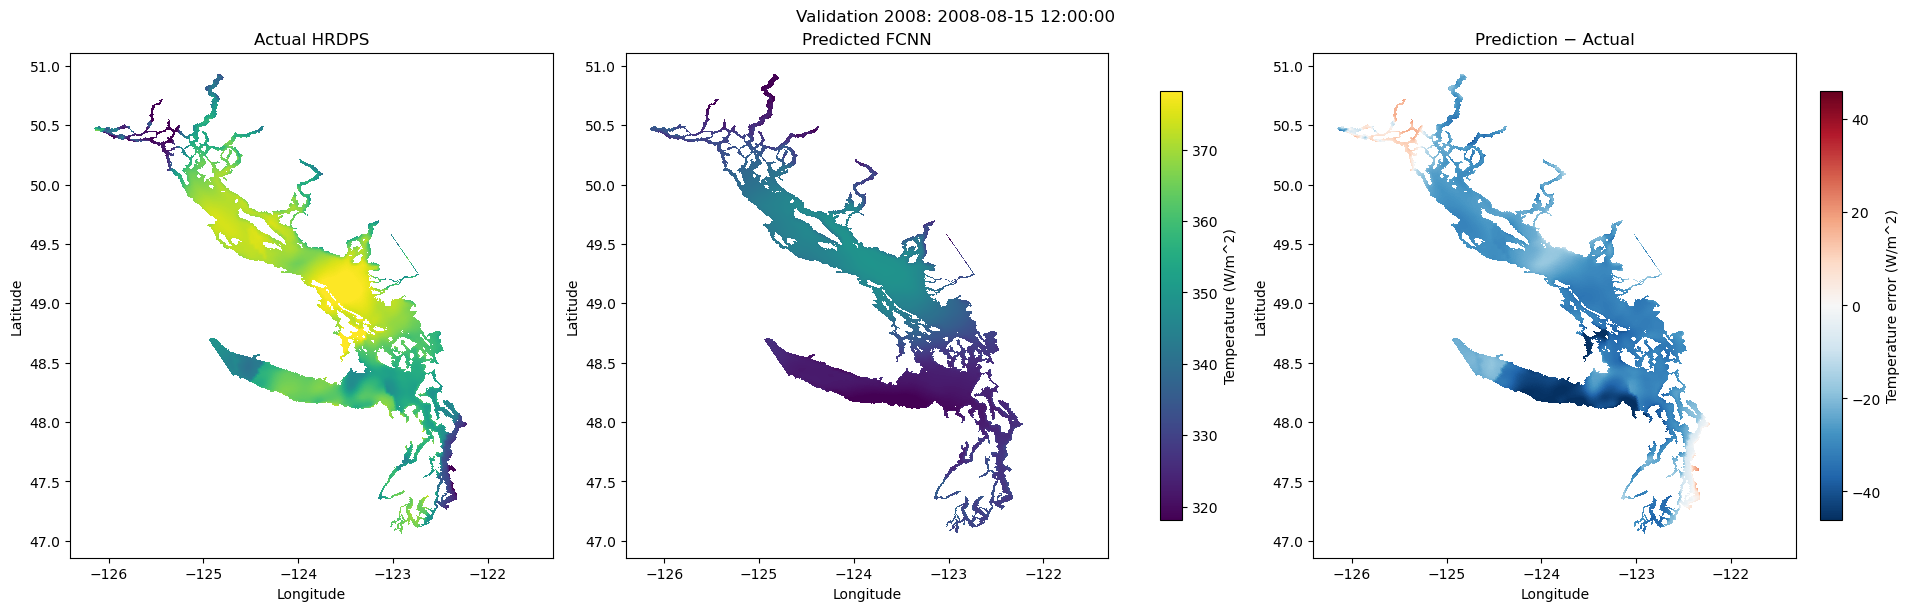

Requested timestamp: 2008-08-15 12:00:00
Selected timestamp: 2008-08-15 12:00:00


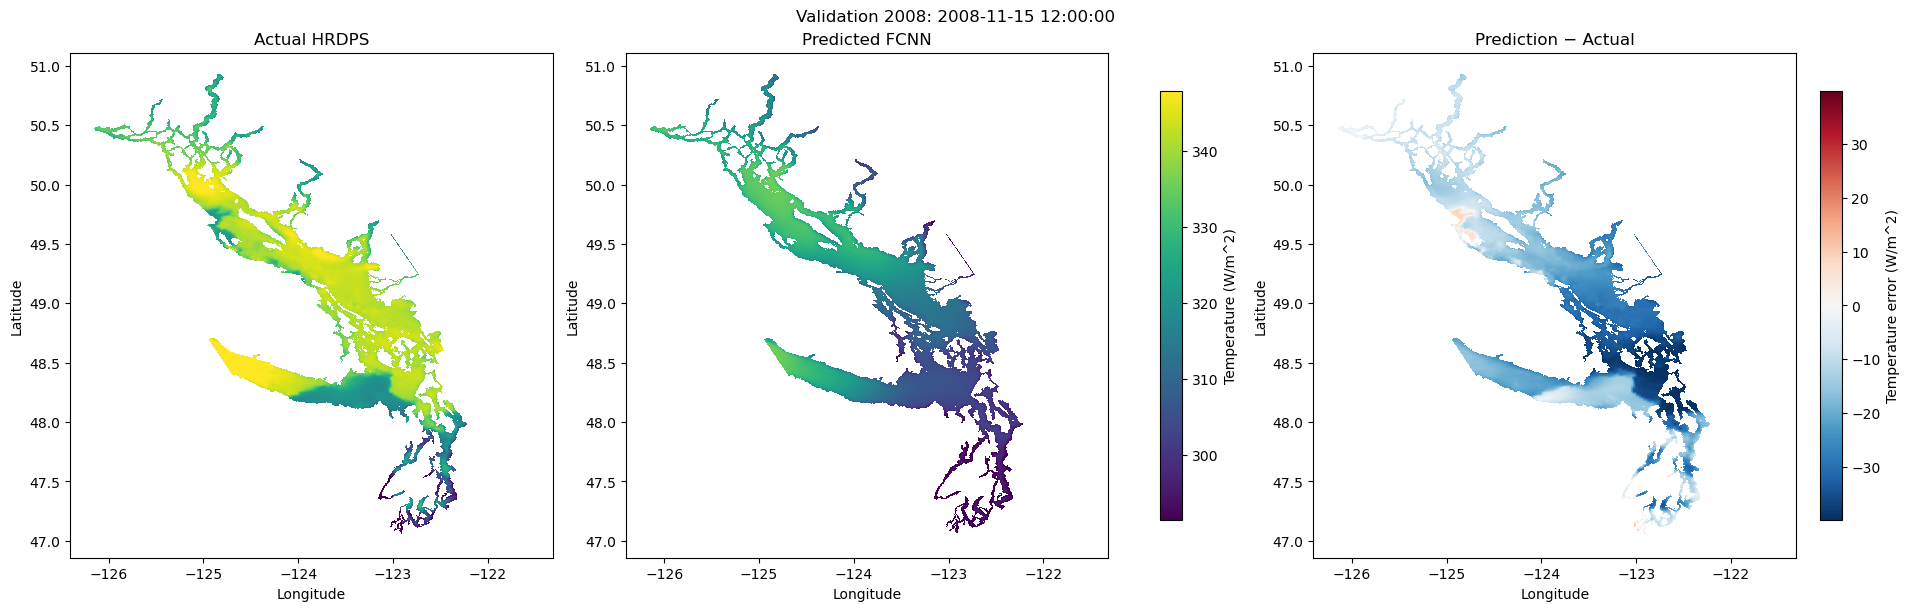

Requested timestamp: 2008-11-15 12:00:00
Selected timestamp: 2008-11-15 12:00:00


In [79]:
validation_spatial_timestamps = [
    "2008-02-15 12:00:00",
    "2008-08-15 12:00:00",
    "2008-11-15 12:00:00",
]

for timestamp in validation_spatial_timestamps:
    plot_spatial_pattern(
        times=val_times,
        true_values=X_hrdps_val,
        predicted_values=X_hrdps_val_pred,
        requested_timestamp=timestamp,
        split_name="Validation 2008",
    )

/tmp/ipykernel_2044018/1886328085.py:15: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  actual_mesh = axes[0].pcolormesh(nemo_lon_2d, nemo_lat_2d, true_map, shading="auto", cmap="viridis", vmin=temperature_vmin, vmax=temperature_vmax)
/tmp/ipykernel_2044018/1886328085.py:19: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  predicted_mesh = axes[1].pcolormesh(nemo_lon_2d, nemo_lat_2d, predicted_map, shading="auto", cmap="viridis", vmin=temperature_vmin, vmax=temperature_vmax)
/tmp/ipykernel_2044018/1886328085.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cel

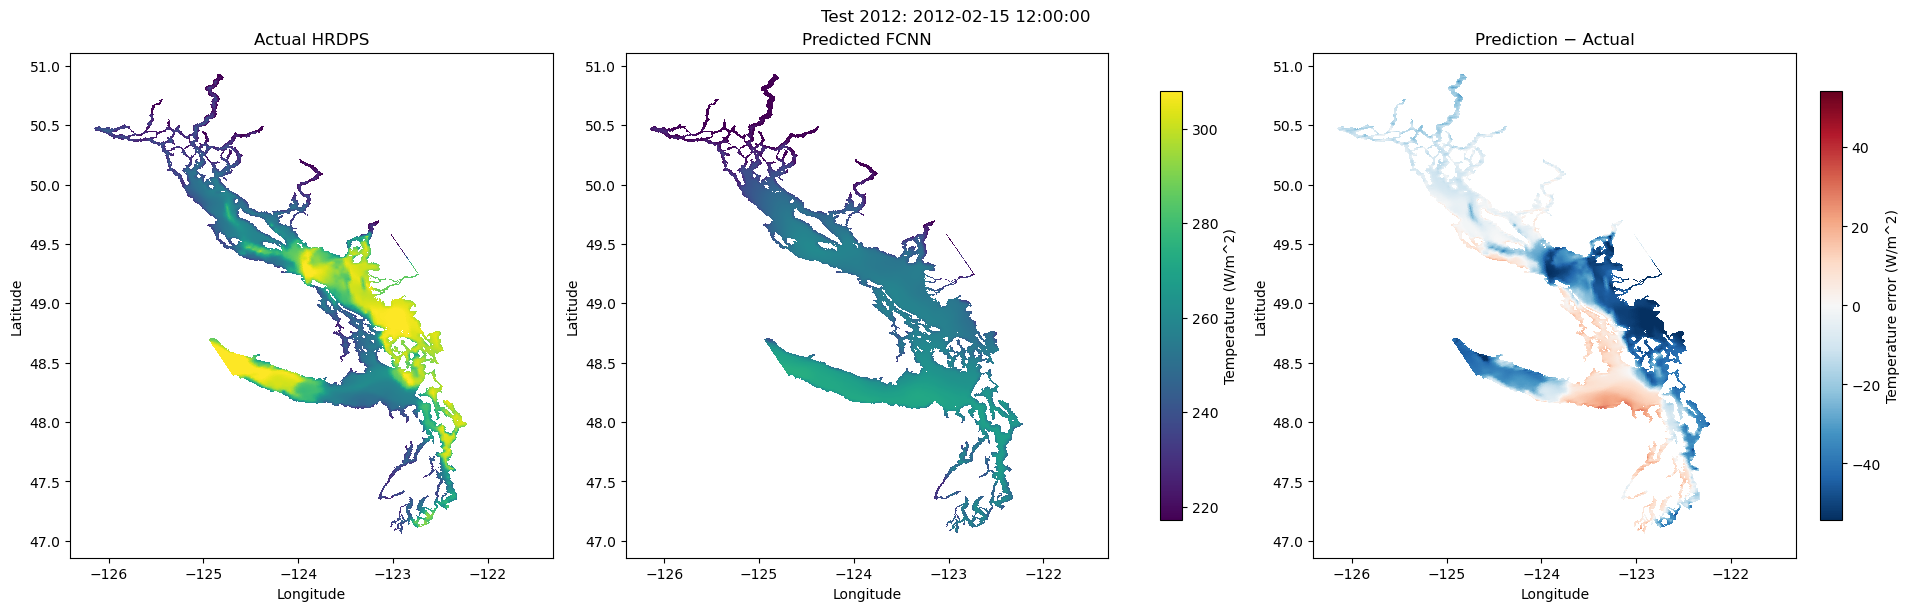

Requested timestamp: 2012-02-15 12:00:00
Selected timestamp: 2012-02-15 12:00:00


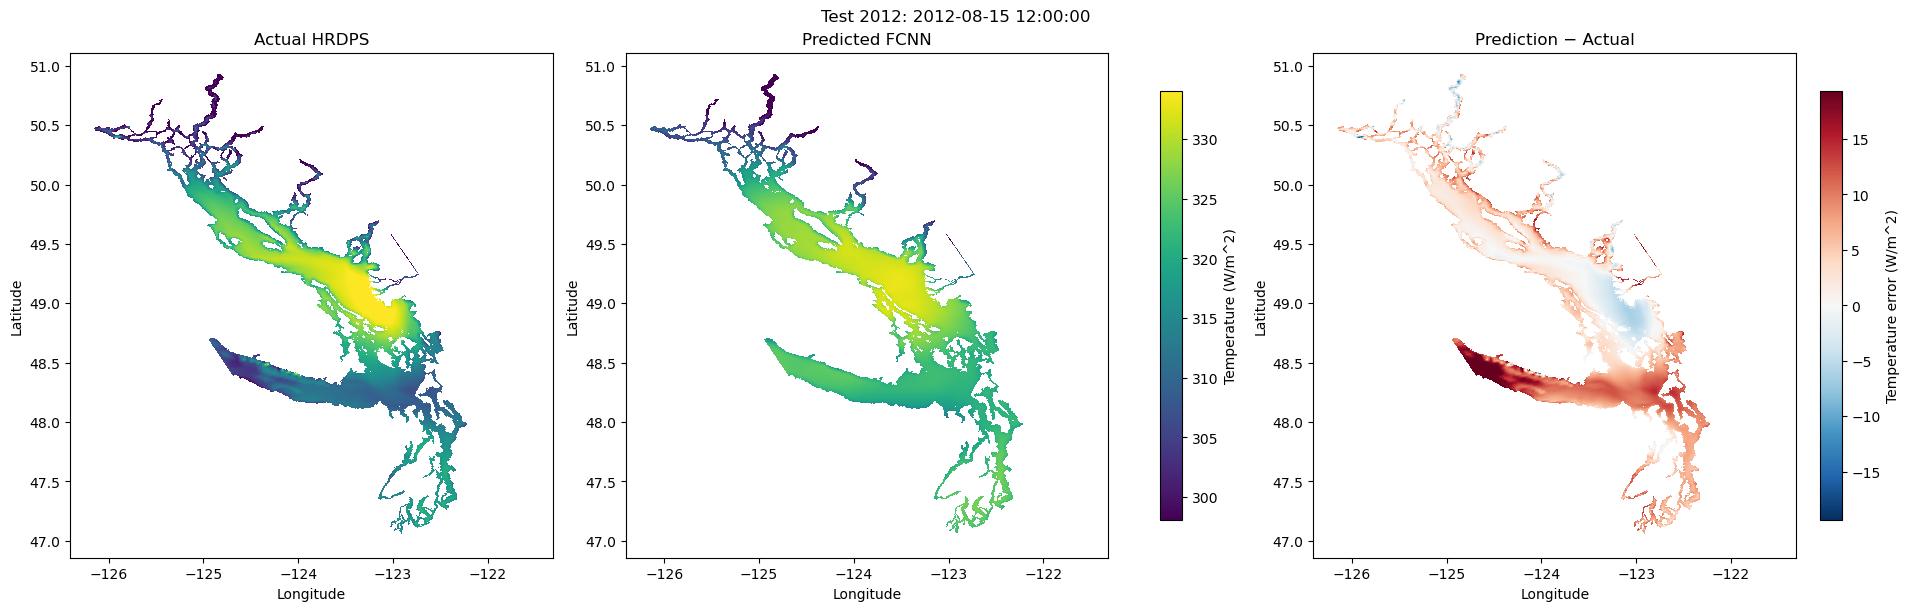

Requested timestamp: 2012-08-15 12:00:00
Selected timestamp: 2012-08-15 12:00:00


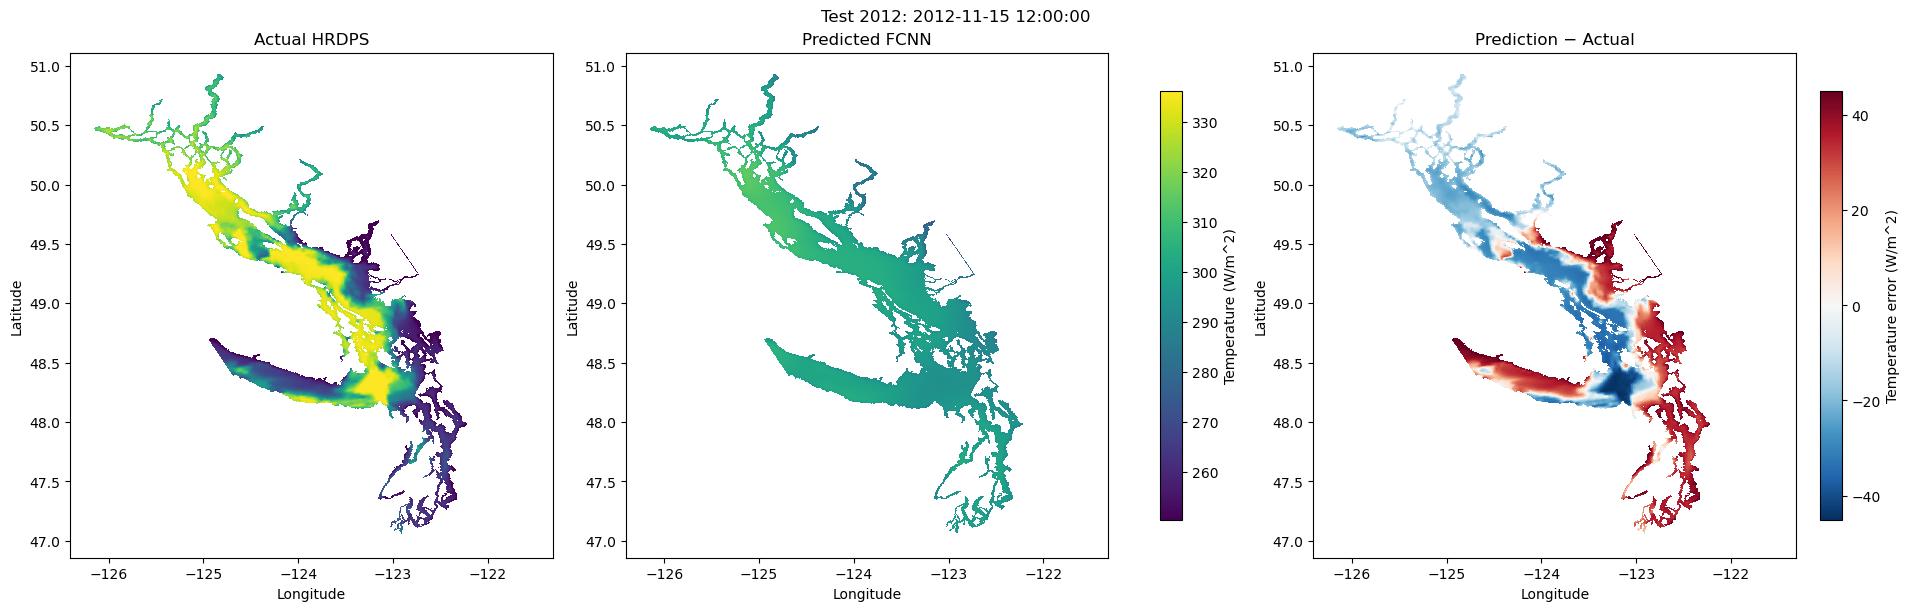

Requested timestamp: 2012-11-15 12:00:00
Selected timestamp: 2012-11-15 12:00:00


In [80]:
test_spatial_timestamps = [
    "2012-02-15 12:00:00",
    "2012-08-15 12:00:00",
    "2012-11-15 12:00:00",
]

for timestamp in test_spatial_timestamps:
    plot_spatial_pattern(
        times=test_times,
        true_values=X_hrdps_test,
        predicted_values=X_hrdps_test_pred,
        requested_timestamp=timestamp,
        split_name="Test 2012",
    )